In [92]:
import pandas as pd
import seaborn as sns
import pm4py

In [93]:
# Load dataset
filepath = 'generated/preprocessed_dataset.csv'
df = pd.read_csv(filepath, parse_dates=["time:timestamp"])

df['case:concept:name'] = df['case:concept:name'].astype(str)
df['time:timestamp']= pd.to_datetime(df['time:timestamp'])

df.head()

,Médico Responsável,Doença,Data Inicial,time:timestamp,concept:name,Item,Data Prescrição,Tempo Processo,Quantidade,Retorno,outlier_label,event_lead_time_min,cumulative_lead_time_min,@@index,@@case_index,case:concept:name
0,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:22:00+00:00,2020-07-21 10:22:00+00:00,Atendimento,Atendimento,NaN,NaN,0.0,Sem retorno,outlier,0.0,0.0,0,0,5446538
1,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:45:00+00:00,2020-07-21 10:49:00+00:00,Triagem,Triagem,NaN,NaN,0.0,Sem retorno,outlier,27.0,27.0,1,0,5446538
2,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:01:00+00:00,2020-07-21 11:01:00+00:00,Exames Laboratoriais,Coronavírus COVID-19 - Diagnóstico Molecular (...,2020-07-21 10:51:00+00:00,9.0,1.0,Sem retorno,outlier,12.0,39.0,2,0,5446538
3,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:32:00+00:00,2020-07-21 11:32:00+00:00,Consulta,Consulta,NaN,NaN,0.0,Sem retorno,outlier,31.0,70.0,3,0,5446538
4,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 19:27:00+00:00,2020-07-21 19:27:00+00:00,Alta,Alta para completar tratamento,NaN,NaN,0.0,Sem retorno,outlier,475.0,545.0,4,0,5446538


concept:name,Alta,Atendimento,Consulta,Exames Eletrofisiológicos,Exames Laboratoriais,Exames de Imagem,Materiais Hospitalares,Medicamentos,Triagem
case:concept:name,,,,,,,,,
5446538,1,1,1,0,1,0,0,0,1
5446540,1,1,1,0,0,1,2,2,1
5446761,1,1,1,0,0,0,0,0,1
5446799,1,1,1,0,0,1,0,0,1
5446806,1,1,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...
5462910,1,1,1,0,0,0,0,0,1
5462929,1,1,1,0,0,0,4,2,1
5462933,1,1,1,0,0,0,0,0,1


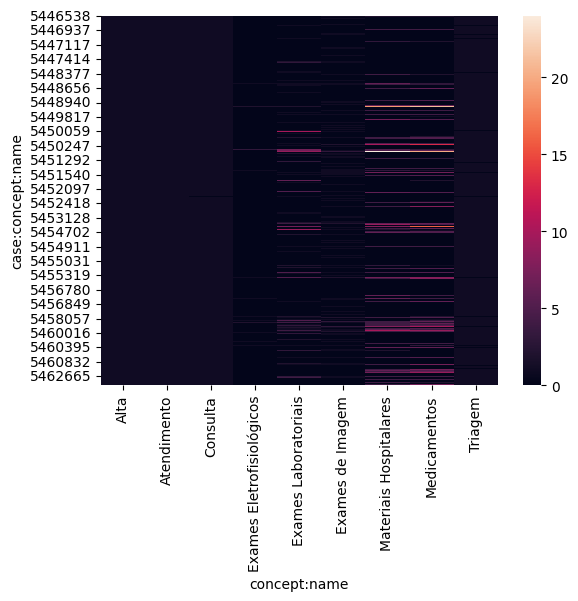

In [94]:
# Create a table giving the number of cases in which each activity is present
activity_frequency = pd.crosstab(df['case:concept:name'], df['concept:name'])
activity_frequency.sort_index(key=lambda x: x.astype(int), inplace=True)

sns.heatmap(activity_frequency)

activity_frequency

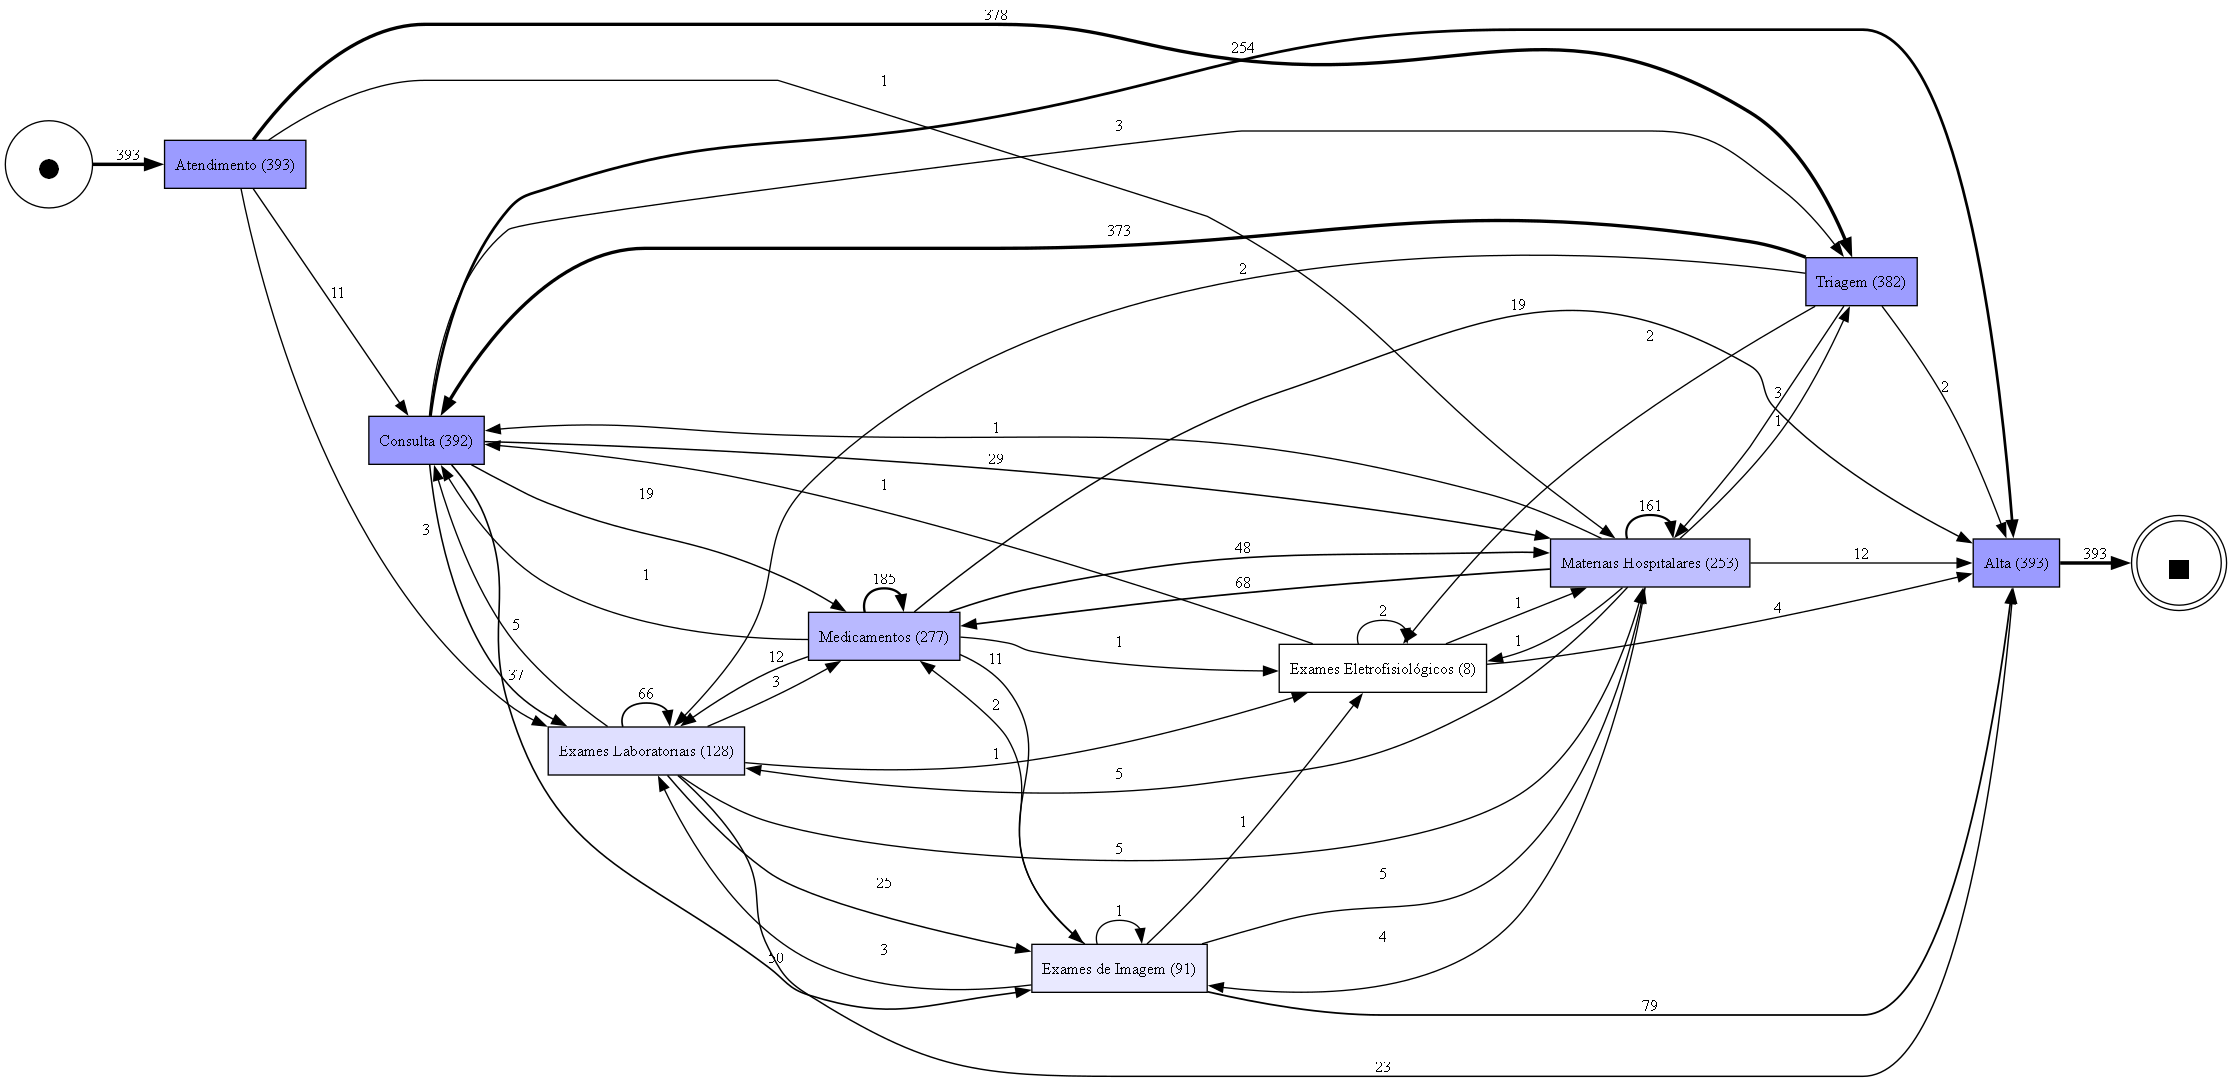

In [96]:
# Discovers a Directly-Follows Graph (DFG) from the log
dfg, start_activities, end_activities = pm4py.discover_dfg(df)

pm4py.view_dfg(dfg, start_activities, end_activities, format='png')

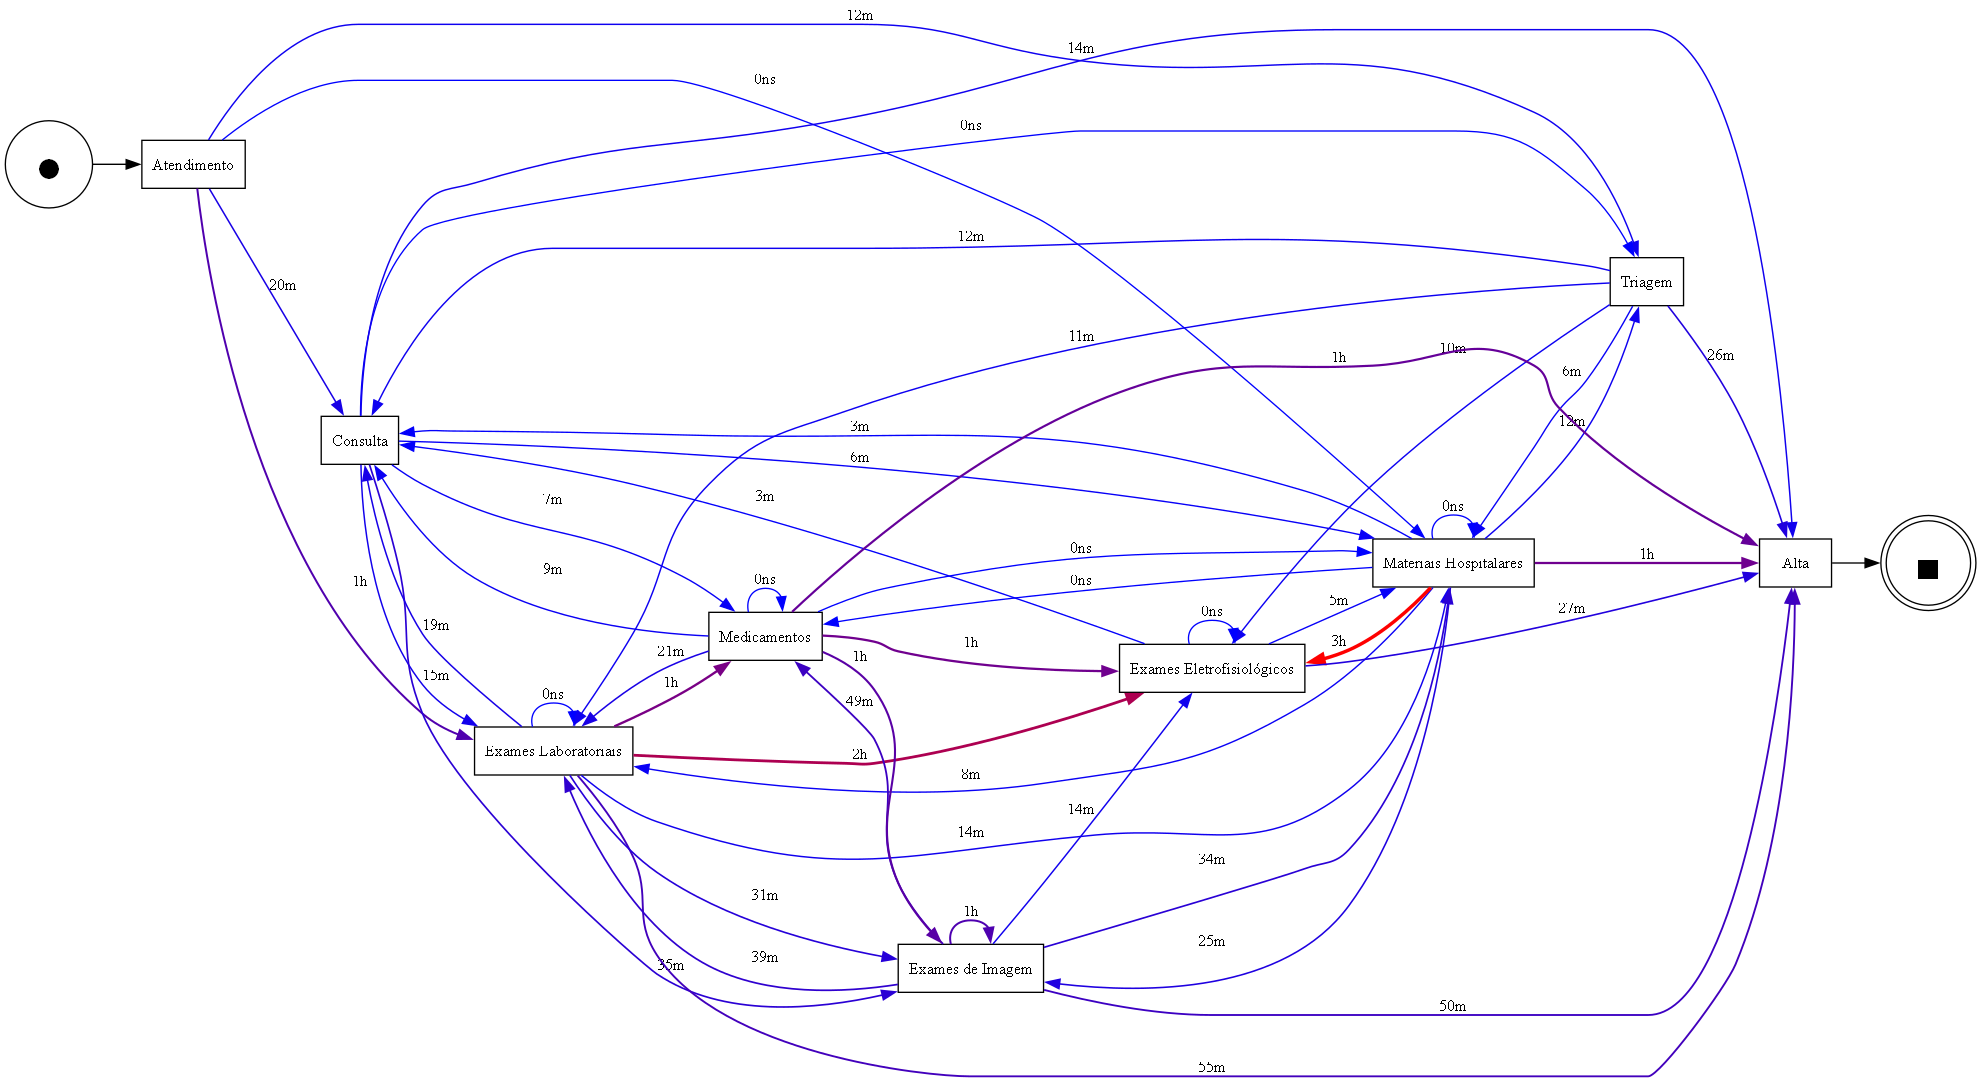

In [97]:
# Dicover and View a performance DFG
performance_dfg, sa, ea = pm4py.discover_performance_dfg(df)

pm4py.view_performance_dfg(performance_dfg, sa, ea, format='png', aggregation_measure='median')

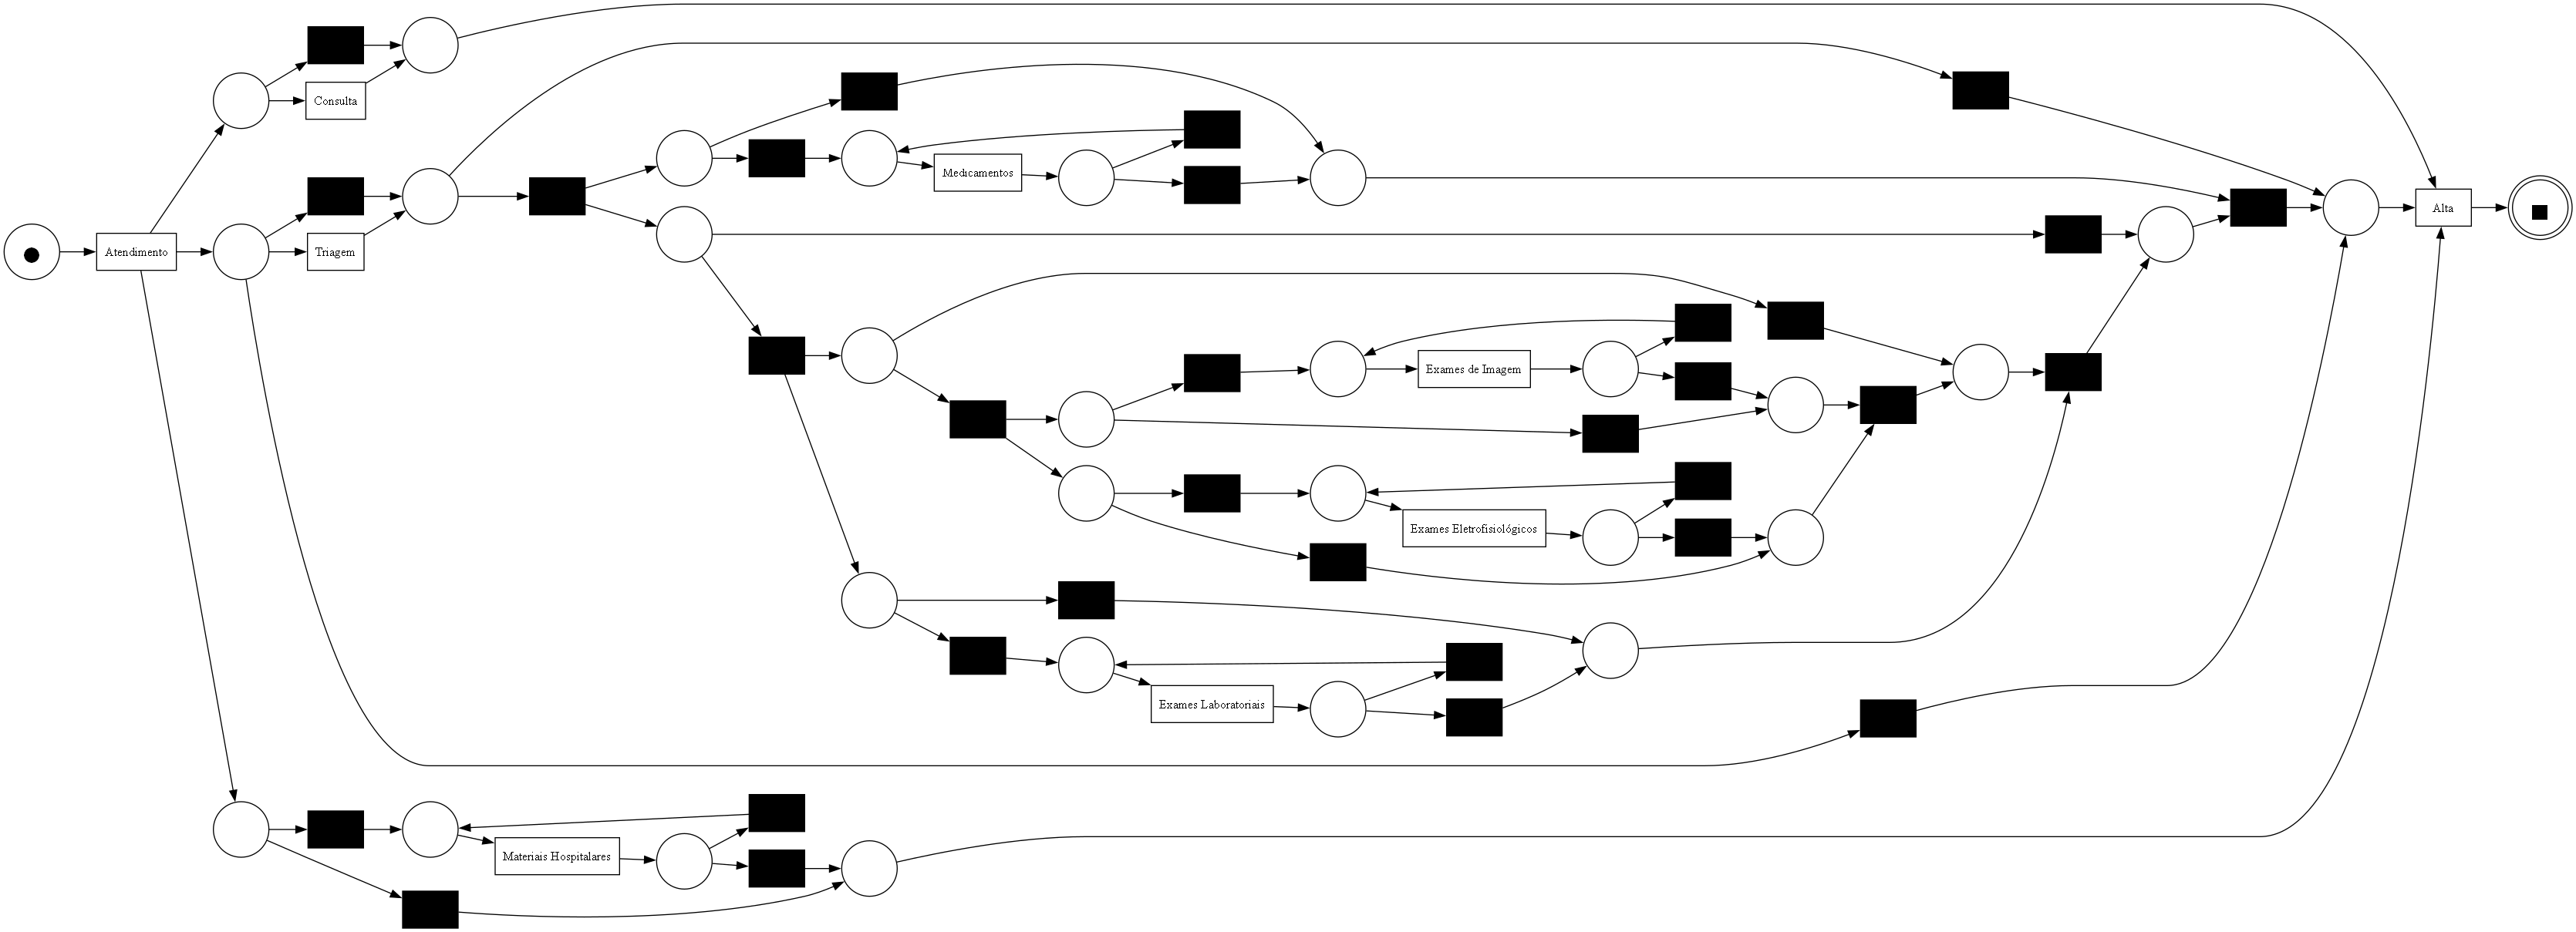

In [98]:
# Discovers a Petri net using the Alpha Miner algorithm.
net, im, fm = pm4py.discover_petri_net_inductive(df)

pm4py.view_petri_net(net, im, fm, format='png')

### Process discovery - inlier

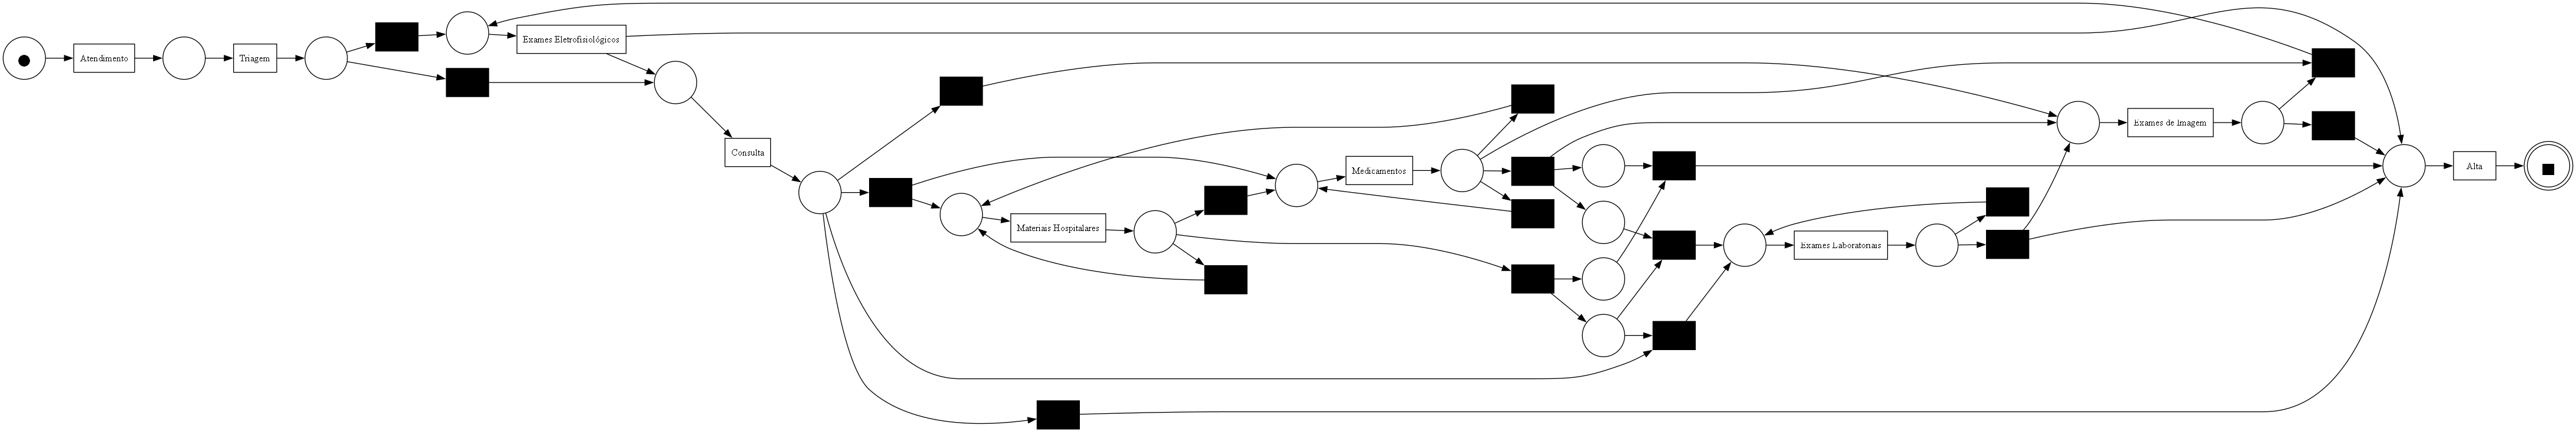

In [99]:
# Process discovery - inlier
df_inlier = df[df["outlier_label"] == "inlier"]

heu_net_in, im, fm = pm4py.discover_petri_net_heuristics(df_inlier)
pm4py.view_petri_net(heu_net_in, im, fm, format='png')

### Process discovery - outlier

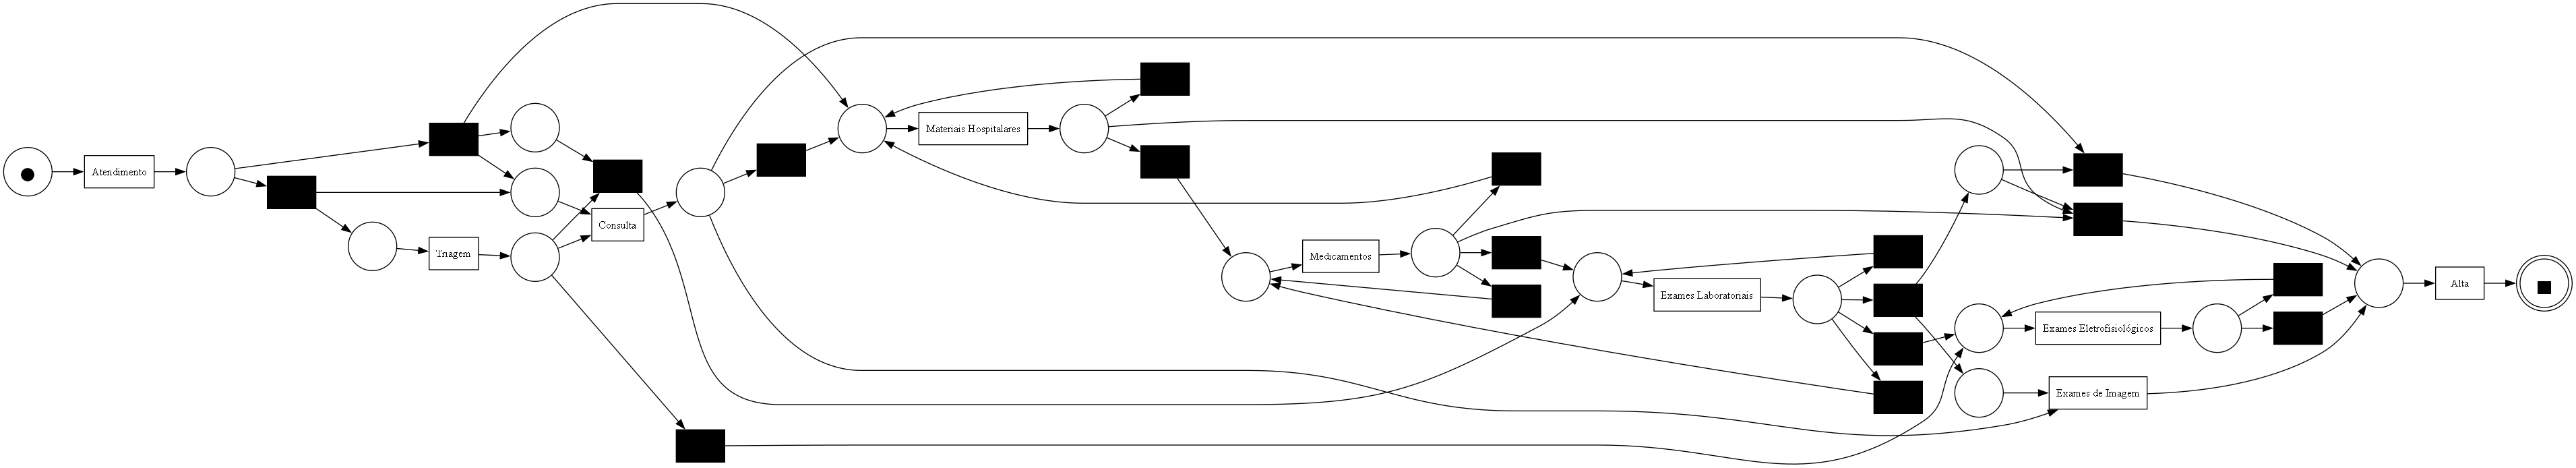

In [100]:
# Process discovery - outlier
df_outlier = df[df["outlier_label"] == "outlier"]

heu_net_out, im, fm = pm4py.discover_petri_net_heuristics(df_outlier)
pm4py.view_petri_net(heu_net_out, im, fm, format='png')